In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

# Demographic data

In [ ]:
# Abrir el archivo en modo lectura
# with open("/home/blaz710/Documents/NeuroIA-Lab/RECORDS.txt", "r", encoding="utf-8") as f:
#     texto = f.read()
# texto=texto.splitlines()

# path_files=list()
# for t in texto:
#     path_files.append(t.split(sep="/")[1])
# path_files

# data=list()
# for k, path in enumerate(path_files):
#     print(k) 
#     url = f"https://physionet.org/content/i-care/2.1/training/{path}/{path}.txt"  # URL del archivo
#     respuesta = requests.get(url)
#     a=respuesta.text.split(sep="Patient: ")[1].splitlines()[:10]
#     dato=list()
#     for i in a:
#         b=i.split(sep=": ")
#         if len(b)==1:
#             dato.append(b[0])
#         else:
#             dato.append(b[1].split(sep="<")[0])
#     data.append(tuple(dato))
# data

In [ ]:
df=pd.read_csv("d/data_patients.csv",sep=";")
df["Age"]=df["Age"].fillna(np.mean(df["Age"]))
for i in df["Sex"][df["Sex"].isnull()].index:
    df["Sex"].iloc[[i]]=np.random.choice(["Male","Female"],p=[0.7,0.3])
df.head(10)

,Id_Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,284,A,53.0,Male,NaN,True,True,33.0,Good,1
1,286,F,85.0,Female,7.0,False,False,NaN,Good,1
2,296,A,48.0,Male,NaN,True,True,36.0,Good,1
3,299,A,45.0,Male,NaN,True,True,33.0,Good,1
4,303,D,51.0,Male,24.0,True,True,33.0,Good,1
5,306,E,73.0,Male,20.0,True,False,33.0,Good,1
6,311,A,39.0,Female,NaN,True,True,33.0,Good,2
7,312,D,51.0,Male,NaN,NaN,True,NaN,Good,1
8,313,B,56.0,Male,3.0,False,False,33.0,Good,1
9,316,D,41.0,Male,37.0,True,True,33.0,Good,1


In [7]:
data_an=pd.read_csv("d/data_features.csv", sep=";")
data_an.sort_values(by=["patient", "hour_file"], inplace=True)
data_an

,id_path,path,data_partition,patient,file,number_file,hour_file,format_data,file_extension,meas_date,minutes,#_channels,channels,fs,time_points
0,533daaa14eb9f3df83a6d8da27674eef8c8cb461617fdb...,training/0284/0284_001_004_ECG.hea,training,284,0284_001_004_ECG.hea,1,4,ECG,hea,NaN,52.62,1.0,ECG,500.0,1578500.0
229,b60649491c45d43cf5e55a4e84f17286fa2498fe6d4f60...,training/0284/0284_001_004_EEG.mat,training,284,0284_001_004_EEG.mat,1,4,EEG,mat,NaN,52.62,19.0,"Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5...",500.0,1578500.0
230,784975be64328c4841e7b3e409a0314daf461b3f7810f4...,training/0284/0284_001_004_EEG.hea,training,284,0284_001_004_EEG.hea,1,4,EEG,hea,NaN,52.62,19.0,"Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5...",500.0,1578500.0
231,9e16951a2f3700b96205424eeb411b520424e4e1c53628...,training/0284/0284_001_004_ECG.mat,training,284,0284_001_004_ECG.mat,1,4,ECG,mat,NaN,52.62,1.0,ECG,500.0,1578500.0
225,3f43c187a0c01e5ba963da202174c999840d8595fb6455...,training/0284/0284_002_005_EEG.mat,training,284,0284_002_005_EEG.mat,2,5,EEG,mat,NaN,60.00,19.0,"Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5...",500.0,1800000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121016,d97ce75f6845a5a6b84da599fce7c4568c7face6de58ca...,training/1020/1020_091_089_EEG.mat,training,1020,1020_091_089_EEG.mat,91,89,EEG,mat,NaN,43.83,19.0,"Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5...",500.0,1315000.0
120787,f67e71395911bcea9054ce4f150d50ed56fc9c06739625...,training/1020/1020_092_090_ECG.hea,training,1020,1020_092_090_ECG.hea,92,90,ECG,hea,NaN,13.72,1.0,ECG,500.0,411500.0
120944,2dafd0486d94b08f26631527db07dee077cc558141ede6...,training/1020/1020_092_090_ECG.mat,training,1020,1020_092_090_ECG.mat,92,90,ECG,mat,NaN,13.72,1.0,ECG,500.0,411500.0
121144,77da05bb0e47f237e2c1d58ef3cd9ec76bc93a7ebe07d4...,training/1020/1020_092_090_EEG.hea,training,1020,1020_092_090_EEG.hea,92,90,EEG,hea,NaN,13.72,19.0,"Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5...",500.0,411500.0


In [6]:

c=data_an["format_data"]=="EEG"
# data_an[(data_an["hour_file"]==48)& c & (data_an["minutes"]<2)].sort_values(by="minutes")
data_an[(data_an["patient"]==991)& c & (data_an["hour_file"]==48)]

,id_path,path,data_partition,patient,file,number_file,hour_file,format_data,file_extension,meas_date,minutes,#_channels,channels,fs,time_points
116008,5584dd1bea20b2a45eb3245fefd42a8d25fcdb07bc2765...,training/0991/0991_048_048_EEG.hea,training,991,0991_048_048_EEG.hea,48,48,EEG,hea,NaN,2.12,20.0,"C3,C4,O1,O2,Cz,F3,F4,F7,F8,Fz,Fp1,Fp2,Fpz,P3,P...",200.0,25400.0
116009,3125c427075681aebe4bcb590018dec706a84848a39524...,training/0991/0991_048_048_EEG.mat,training,991,0991_048_048_EEG.mat,48,48,EEG,mat,NaN,2.12,20.0,"C3,C4,O1,O2,Cz,F3,F4,F7,F8,Fz,Fp1,Fp2,Fpz,P3,P...",200.0,25400.0


In [ ]:
# df_analysis=pd.read_csv("link_data_file.csv",sep=";")
# list_data=os.listdir("d")
# list_data=[x for x in list_data if "0" in x]
# df_aux=pd.DataFrame(columns=df_analysis.columns)
# df_aux

# for f in list_data:
#     aux=pd.read_csv("d/"+f,sep=";")
#     df_aux=pd.concat([df_aux,aux])
# df_final=pd.concat([df_analysis, df_aux])
# df_final.sort_values(by="patient",inplace=True)
# df_final.dropna(subset="channels", inplace=True)
# df_final.drop_duplicates(subset="id_path",inplace=True)
# df_final.reset_index(drop=True, inplace=True)
# df_final.to_csv("d/data_features.csv", sep=";", index=False)

<Axes: xlabel='Outcome', ylabel='Count'>

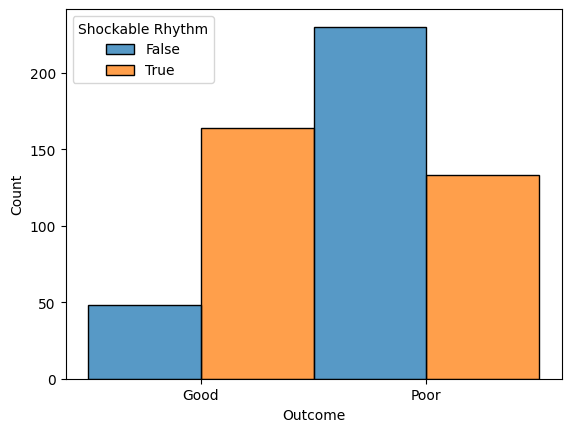

In [5]:
sns.histplot(data=df, hue="Shockable Rhythm", x="Outcome",multiple="dodge")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id_Patient        607 non-null    int64  
 1   Hospital          607 non-null    object 
 2   Age               607 non-null    float64
 3   Sex               607 non-null    object 
 4   ROSC              303 non-null    float64
 5   OHCA              566 non-null    object 
 6   Shockable Rhythm  575 non-null    object 
 7   TTM               509 non-null    float64
 8   Outcome           607 non-null    object 
 9   CPC               607 non-null    int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 47.6+ KB


In [21]:
dict_hospital={"A":1, "B":2, "C":3, "D":4, "E":5, "F":6}
dict_sex={"Male":1, "Female":2}
dict_outcome={"Good":1, "Poor":2}